In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
car=pd.read_csv('cardekho.csv')

In [3]:
car.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [4]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [5]:
car.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [6]:
car.shape

(8128, 12)

<Axes: xlabel='fuel', ylabel='count'>

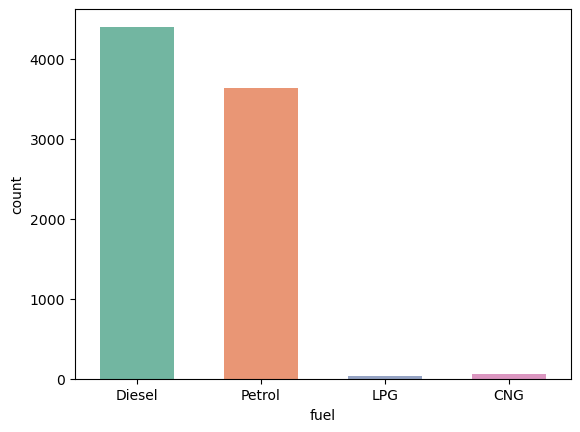

In [7]:
sns.countplot(data=car, x='fuel', hue='fuel', palette='Set2', legend=False, width=0.6)

<Axes: xlabel='owner', ylabel='count'>

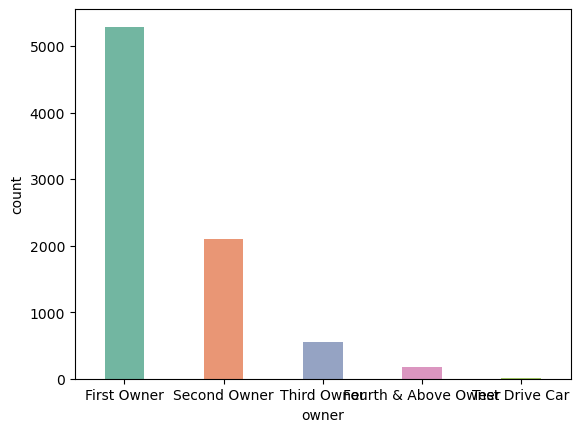

In [8]:
sns.countplot(data=car, x='owner', hue='owner', palette='Set2', legend=False, width=0.4)

<Axes: xlabel='seller_type', ylabel='count'>

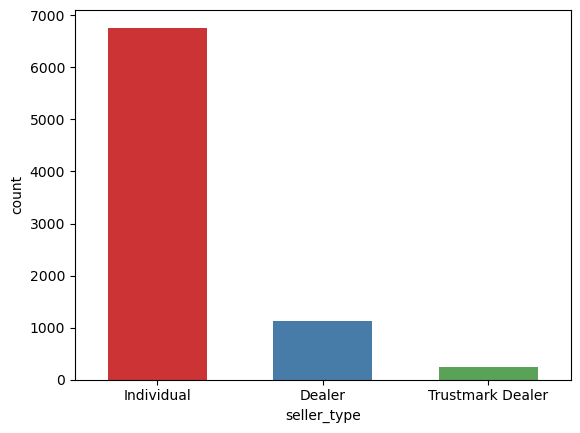

In [9]:
sns.countplot(data=car, x='seller_type', hue='seller_type', palette='Set1', legend=False, width=0.6)

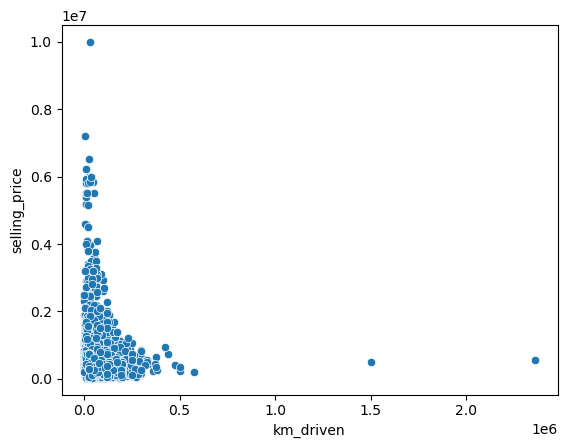

In [10]:
sns.scatterplot(data=car, x="km_driven", y="selling_price")
plt.show()

<Axes: xlabel='transmission', ylabel='count'>

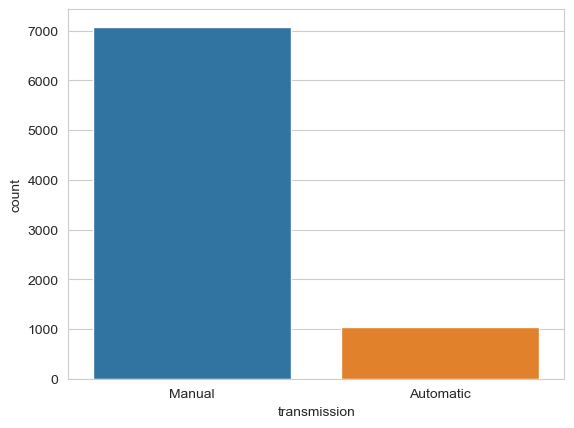

In [11]:
sns.set_style('whitegrid')
sns.countplot(x='transmission', hue='transmission', data=car)

<Axes: xlabel='seats', ylabel='count'>

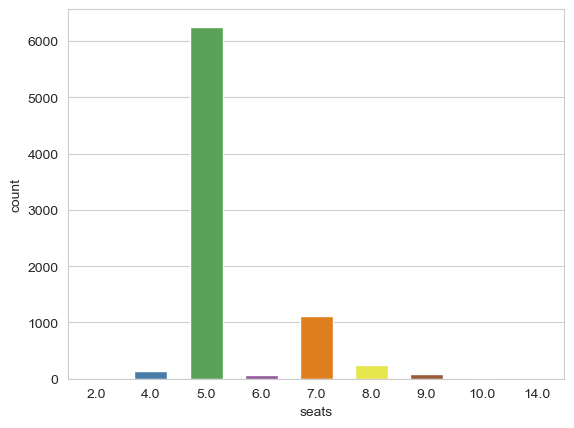

In [12]:
sns.countplot(data=car, x='seats', hue='seats', palette='Set1', legend=False, width=0.6)

In [13]:
car['seats'].value_counts()

seats
5.0     6254
7.0     1120
8.0      236
4.0      133
9.0       80
6.0       62
10.0      19
2.0        2
14.0       1
Name: count, dtype: int64

In [14]:
car.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [15]:
car.shape

(8128, 12)

In [16]:
car['name']=car['name'].str.split().str.slice(0,3).str.join(' ')

In [21]:
car['company']=car['name'].str.split().str.slice(0,1).str.join(' ')

In [17]:
car=car.drop(['mileage(km/ltr/kg)', 'engine', 'max_power', 'seats'], axis=1)

In [22]:
car.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,company
0,Maruti Swift Dzire,2014,450000,145500,Diesel,Individual,Manual,First Owner,Maruti
1,Skoda Rapid 1.5,2014,370000,120000,Diesel,Individual,Manual,Second Owner,Skoda
2,Honda City 2017-2020,2006,158000,140000,Petrol,Individual,Manual,Third Owner,Honda
3,Hyundai i20 Sportz,2010,225000,127000,Diesel,Individual,Manual,First Owner,Hyundai
4,Maruti Swift VXI,2007,130000,120000,Petrol,Individual,Manual,First Owner,Maruti


In [23]:
car.to_csv('cleaned_car.csv')

In [24]:
x=car.drop('selling_price', axis=1)
y=car['selling_price']

In [25]:
y.head()

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train, Y_test=train_test_split(x, y, test_size=0.2)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [28]:
num_cols=car.select_dtypes(include=['int64', 'float64']).columns.drop('selling_price')
cat_cols=car.select_dtypes(include=['object']).columns

In [29]:
preprocesser=ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

model=Pipeline(steps=[
    ('preprocesser', preprocesser),
    ('regresser', LinearRegression())
])

In [30]:
model.fit(X_train, Y_train)

,steps,"[('preprocesser', ...), ('regresser', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred=model.predict(X_test)

C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [32]:
r2_score(Y_test, y_pred)

0.8111359506815542

In [28]:
# ohe=OneHotEncoder()
# ohe.fit(x[['name', 'fuel', 'seller_type', 'transmission', 'owner']])

In [29]:
# column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name', 'fuel', 'seller_type', 'transmission', 'owner']),
#                                remainder='passthrough')

In [30]:
# lr=LinearRegression()

In [31]:
# pipe=make_pipeline(column_trans, lr)

In [32]:
# pipe.fit(X_train, Y_train)

In [33]:
# Y_pred=pipe.predict(X_test)

In [34]:
# r2_score(Y_test, Y_pred)

In [35]:
# score=[]
# for i in range(1000):
#     x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=i)
#     lr=LinearRegression()
#     pipe=make_pipeline(column_trans, lr)
#     pipe.fit(x_train, y_train)
#     y_pred=pipe.predict(x_test)
#     score.append(r2_score(y_test, y_pred))

In [36]:
# np.argmax(score)

In [37]:
# score[np.argmax(score)]

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso, LassoCV
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet

In [34]:
lr=LinearRegression()
dtr=DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)
xgb=XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
rfr=RandomForestRegressor(n_estimators=300, max_depth=None, max_features='sqrt', min_samples_leaf=2, random_state=42, n_jobs=-1)
rd=Ridge(alpha=0.1)
ls=Lasso(alpha=0.01)
svr=SVR(kernel='rbf', C=1.0, epsilon=0.1)
enr=ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)

In [35]:
regs={
    'LR':lr,
    'DTR':dtr,
    'XGB':xgb,
    'RFR':rfr,
    'RD':rd,
    'LS':ls,
    'SVR':svr,
    'ENR':enr
}

In [36]:
def train_regressor(reg, X_train, Y_train, X_test, Y_test):
    preprocesser=ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
        ],
        remainder='passthrough'
    )
    
    model=Pipeline(steps=[
        ('preprocesser', preprocesser),
        ('regresser', reg)
    ])
    model.fit(X_train, Y_train)
    y_pred=model.predict(X_test)
    rtwoscore=r2_score(Y_test, y_pred)
    return rtwoscore

In [37]:
train_regressor(svr, X_train, Y_train, X_test, Y_test)

C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


-0.0640826807256305

In [38]:
scores = []

for name, reg in regs.items():
    r2score = train_regressor(reg, X_train, Y_train, X_test, Y_test)
    print("for ", name)
    print("r2score - ", r2score)
    scores.append(r2score)

C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


for  LR
r2score -  0.8111359506815542
for  DTR
r2score -  0.780399497190456


C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


for  XGB
r2score -  0.9119651317596436


C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.868e+13, tolerance: 3.965e+11
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


for  LS
r2score -  0.896997864185251


C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


for  SVR
r2score -  -0.0640826807256305
for  ENR
r2score -  0.5915384100126427


C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [39]:
preprocesser=ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)
    
model=Pipeline(steps=[
    ('preprocesser', preprocesser),
    ('regresser',XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42))
])

In [40]:
model.fit(X_train, Y_train)

,steps,"[('preprocesser', ...), ('regresser', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
Y_pred=model.predict(X_test)

C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [42]:
r2_score(Y_test, Y_pred)

0.9119651317596436

In [43]:
import pickle

In [44]:
pickle.dump(model, open('model.pkl', 'wb'))

In [48]:
input_df = pd.DataFrame(
    [['Maruti Suzuki Swift', 2013, 145000, 'Diesel', 'Individual', 'Manual', 'First Owner', 'Maruti']],
    columns=['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'company']
)
model.predict(input_df)

C:\Users\vikas\anaconda3\dataanv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([390414.], dtype=float32)